## 1️⃣ Import Libraries

In [2]:

import re
import nltk
import shap
import torch
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import BertTokenizer, BertModel
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score
from textblob import TextBlob
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE

# Download stopwords
nltk.download("stopwords")
stop_words = set(nltk.corpus.stopwords.words("english"))


[nltk_data] Error loading stopwords: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     self-signed certificate in certificate chain
[nltk_data]     (_ssl.c:1000)>


## 2️⃣ Load Dataset

In [3]:

splits = {'train': 'train.csv', 'validation': 'valid.csv', 'test': 'test.csv'}
df = pd.read_csv("hf://datasets/chengxuphd/liar2/" + splits["train"])
df.head()


,id,label,statement,date,subject,speaker,speaker_description,state_info,true_counts,mostly_true_counts,half_true_counts,mostly_false_counts,false_counts,pants_on_fire_counts,context,justification
0,13847,5,"90 percent of Americans ""support universal bac...","October 2, 2017",government regulation;polls and public opinion...,chris abele,"Chris Abele is Milwaukee County Executive, a p...",wisconsin,1,4,5,3,5,2,a tweet,"""Universal"" is the term for background checks ..."
1,13411,1,Last year was one of the deadliest years ever ...,"May 19, 2017",after the fact;congress;criminal justice;histo...,thom tillis,Thom Tillis is a Republican who serves as U.S....,north carolina,0,2,7,3,2,0,a press release supporting the Back The Blue A...,"Sen. Thom Tillis, a North Carolina Republican,..."
2,10882,0,"Bernie Sanders's plan is ""to raise your taxes ...","October 28, 2015",taxes,chris christie,"Chris Christie announced June 6, 2023 that he ...",national,21,20,27,11,17,8,"Boulder, Colo","Christie said that Sanders’s plan is ""to raise..."
3,20697,4,Voter ID is supported by an overwhelming major...,"December 8, 2021",voter id laws,lee zeldin,Lee Zeldin is a Republican representing New Yo...,new york,1,2,0,0,0,0,a Tweet,Zeldin claimed voter identification requiremen...
4,6095,2,"Says Barack Obama ""robbed Medicare (of) $716 b...","August 12, 2012",federal budget;history;medicare;retirement,mitt romney,Mitt Romney is a U.S. senator from Utah. He ra...,national,31,33,58,35,32,19,"an interview on ""60 Minutes""","Romney said, ""There's only one president that ..."


## 3️⃣ Data Preprocessing & Feature Engineering

In [4]:

# Text Preprocessing Function
def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'\W+', ' ', text)
    text = " ".join([word for word in text.split() if word not in stop_words])
    return text

df["processed_text"] = df["statement"].apply(preprocess_text)

# Handle Missing Values
def randomsampleimputation(df, variable):
    random_sample = df[variable].dropna().sample(df[variable].isnull().sum(), random_state=0)
    random_sample.index = df[df[variable].isnull()].index
    df.loc[df[variable].isnull(), variable] = random_sample

for col in ["speaker", "state_info", "context"]:
    randomsampleimputation(df, col)


## 4️⃣ Load BERT Model & Extract Embeddings

In [5]:

# Load BERT Model & Tokenizer
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
bert_model = BertModel.from_pretrained("bert-base-uncased")

def get_bert_embedding(text):
    tokens = tokenizer(text, padding='max_length', max_length=50, truncation=True, return_tensors="pt")
    with torch.no_grad():
        outputs = bert_model(**tokens)
    return outputs.last_hidden_state[:, 0, :].squeeze().numpy()

df["bert_embedding"] = df["processed_text"].apply(get_bert_embedding)


## 5️⃣ Sentiment Analysis

In [6]:

def get_sentiment(text):
    sentiment = TextBlob(text).sentiment
    return sentiment.polarity, sentiment.subjectivity

df["sentiment_polarity"], df["sentiment_subjectivity"] = zip(*df["processed_text"].apply(get_sentiment))


## 6️⃣ Encode Categorical Features

In [7]:

encoder = LabelEncoder()
df["speaker"] = encoder.fit_transform(df["speaker"])
df["state_info"] = encoder.fit_transform(df["state_info"])
df["context"] = encoder.fit_transform(df["context"])


## 7️⃣ Feature Scaling & Class Balancing

In [8]:

metadata_features = df[[
    "speaker", "state_info", "context", "true_counts", "mostly_true_counts", 
    "half_true_counts", "mostly_false_counts", "false_counts", "pants_on_fire_counts",
    "sentiment_polarity", "sentiment_subjectivity"
]]

scaler = StandardScaler()
X_metadata = scaler.fit_transform(metadata_features)

# Merge Metadata & BERT Embeddings
X_bert = np.vstack(df["bert_embedding"].values)
X_combined = np.hstack((X_metadata, X_bert))
y = df["label"]  # Assuming 'label' is the target column

# Handle Class Imbalance
smote = SMOTE(random_state=42)
X_combined, y = smote.fit_resample(X_combined, y)


## 8️⃣ Train-Test Split

In [9]:

X_train, X_test, y_train, y_test = train_test_split(X_combined, y, test_size=0.2, random_state=42)


## 9️⃣ Train Hybrid Model: XGBoost + BERT

In [10]:

xgb_model = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=5)
xgb_model.fit(X_train, y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, objective='multi:softprob', ...)

## 🔟 Model Evaluation

In [11]:

# Predictions & Evaluation
y_pred = xgb_model.predict(X_test)
print("XGBoost Classification Report:")
print(classification_report(y_test, y_pred))


XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.75      0.70      1045
           1       0.60      0.52      0.56      1088
           2       0.56      0.47      0.51      1027
           3       0.60      0.51      0.55      1053
           4       0.58      0.63      0.60      1062
           5       0.61      0.74      0.67      1066

    accuracy                           0.60      6341
   macro avg       0.60      0.60      0.60      6341
weighted avg       0.60      0.60      0.60      6341



## 1️⃣1️⃣ SHAP Explainability

100%|===================| 38006/38046 [09:13<00:00]        

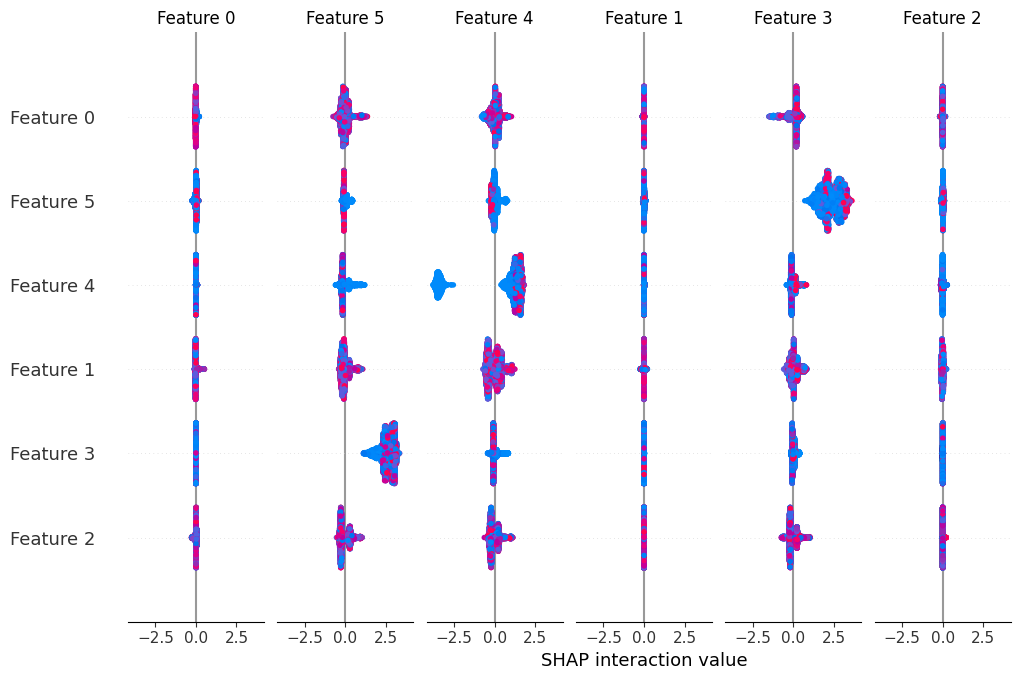

In [12]:

# SHAP Explainability
explainer = shap.Explainer(xgb_model, X_train)
shap_values = explainer(X_test)

# Feature Importance Plot
shap.summary_plot(shap_values, X_test)


## 1️⃣2️⃣ Correlation Analysis

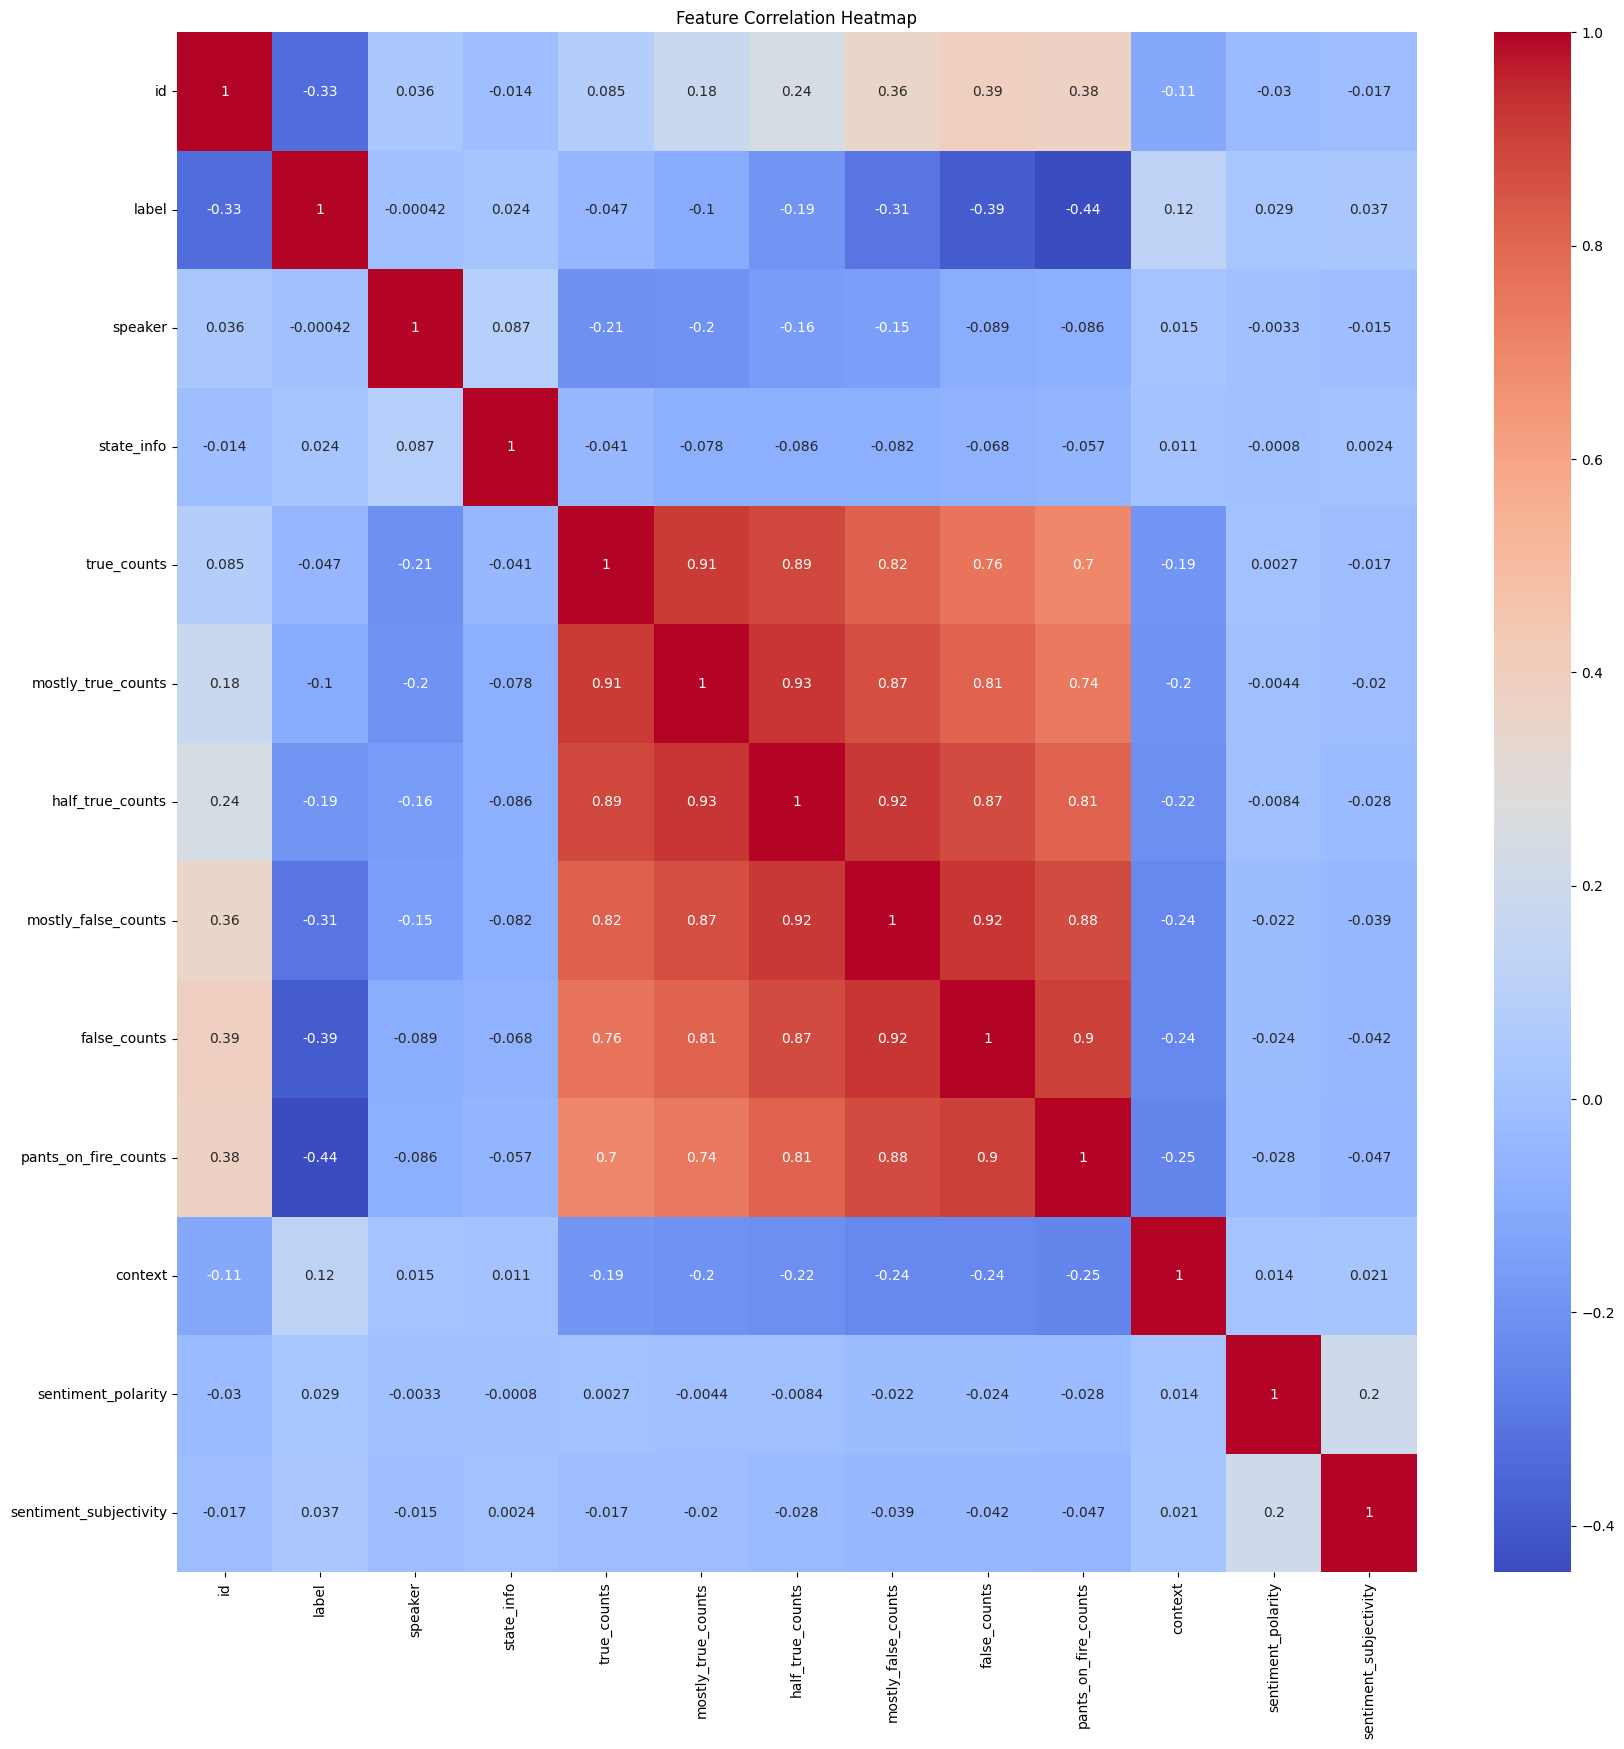

In [13]:
# Select only numeric columns
numeric_df = df.select_dtypes(include=['number'])

# Compute Spearman correlation on numeric data only
corrmat = numeric_df.corr(method="spearman")

# Plot
plt.figure(figsize=(20, 20))
sns.heatmap(corrmat, annot=True, cmap="coolwarm")  # Optional: set cmap
plt.title("Feature Correlation Heatmap")
plt.show()


## 1️⃣3️⃣ Compare with Other Models

In [14]:

models = {
    "SVM": SVC(),
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(n_estimators=100)
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f"{name} Accuracy:", accuracy_score(y_test, y_pred))


SVM Accuracy: 0.41823056300268097


c:\Users\senth\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression Accuracy: 0.3945749881722126
Random Forest Accuracy: 0.7307995584292698


## 1️⃣4️⃣ Cross-Validation for Robustness

In [15]:

scores = cross_val_score(xgb_model, X_train, y_train, cv=5)
print("XGBoost Cross-Validation Accuracy:", scores.mean())


XGBoost Cross-Validation Accuracy: 0.6114024516506948


## 1️⃣5️⃣ Feature Importance Analysis

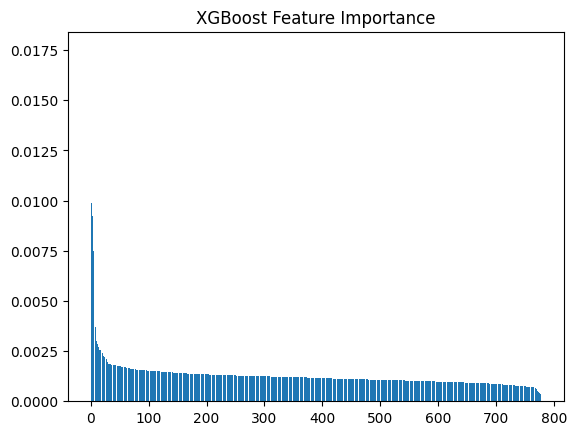

In [16]:

importances = xgb_model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure()
plt.title("XGBoost Feature Importance")
plt.bar(range(X_train.shape[1]), importances[indices])
plt.show()


## 1️⃣6️⃣ Error Analysis

In [17]:

misclassified_indices = np.where(y_pred != y_test)[0]
misclassified_data = df.iloc[misclassified_indices]
print("Examples of Misclassified Fake News:\n", misclassified_data.head(5))


Examples of Misclassified Fake News:
        id  label                                          statement  \
12  11102      5  Guantanamo has "never been a key component of ...   
19   8037      5  A million people … could get health insurance ...   
20  19947      1  'LOL' stands for 'Lucifer our Lord.' Satanists...   
26  12756      0  Donald Trump Protester Speaks Out: 'I Was Paid...   
29  12049      3  Says Hillary Clinton "has called for a radical...   

                 date                                            subject  \
12  December 27, 2015                               terrorism;punditfact   
19   November 6, 2013                               health care;medicaid   
20      June 26, 2021                               facebook fact-checks   
26  November 11, 2016                                          fake news   
29      July 21, 2016  immigration;homeland security;human rights;for...   

    speaker                                speaker_description  state_info  \


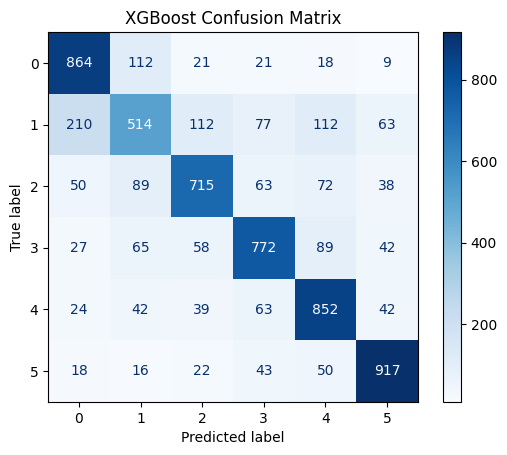

In [18]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("XGBoost Confusion Matrix")
plt.show()


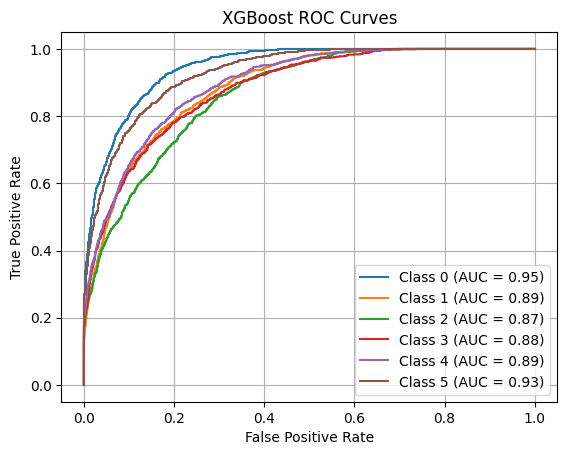

In [19]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import RocCurveDisplay

# Only for multi-class with probabilities
y_score = xgb_model.predict_proba(X_test)
y_bin = label_binarize(y_test, classes=np.unique(y))

for i in range(y_bin.shape[1]):
    fpr, tpr, _ = roc_curve(y_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {i} (AUC = {roc_auc:.2f})')

plt.title('XGBoost ROC Curves')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid()
plt.show()


In [20]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [3, 5, 7],
    'n_estimators': [50, 100],
    'learning_rate': [0.01, 0.1]
}
grid = GridSearchCV(XGBClassifier(), param_grid, cv=3, scoring='accuracy')
grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best Score:", grid.best_score_)


Best Parameters: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 100}
Best Score: 0.6557977073874496


In [21]:
from xgboost import XGBClassifier

# Train final model with best parameters
best_model = XGBClassifier(
    learning_rate=0.1,
    max_depth=7,
    n_estimators=100
)
best_model.fit(X_train, y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=7, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, objective='multi:softprob', ...)

In [22]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

y_pred = best_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.6890080428954424
Confusion Matrix:
 [[834 121  33  21  17  19]
 [172 630  98  64  70  54]
 [ 62 101 612  84  93  75]
 [ 28  69  95 662 115  84]
 [ 24  49  58  72 765  94]
 [ 24  31  35  50  60 866]]
Classification Report:
               precision    recall  f1-score   support

           0       0.73      0.80      0.76      1045
           1       0.63      0.58      0.60      1088
           2       0.66      0.60      0.63      1027
           3       0.69      0.63      0.66      1053
           4       0.68      0.72      0.70      1062
           5       0.73      0.81      0.77      1066

    accuracy                           0.69      6341
   macro avg       0.69      0.69      0.69      6341
weighted avg       0.69      0.69      0.69      6341



In [23]:
import joblib

joblib.dump(best_model, "final_model.pkl")


['final_model.pkl']

In [25]:
import os
os.environ["HF_HOME"] = "D:/my_huggingface_cache"


In [29]:
from utils import preprocess_text

# Create a new column with preprocessed text
df['cleaned_text'] = df['statement'].apply(preprocess_text)


In [30]:
import numpy as np
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
import pickle
from utils import get_bert_embedding

# Create X and y using only BERT embeddings
X = np.array([get_bert_embedding(text) for text in df['cleaned_text']])
y = df['label'].values

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the model
model = XGBClassifier()
model.fit(X_train, y_train)

# Save the model
with open("model.pkl", "wb") as f:
    pickle.dump(model, f)

print("✅ Model trained and saved using only BERT embeddings.")


✅ Model trained and saved using only BERT embeddings.


In [1]:
print("Label distribution:\n", df["label"].value_counts())


NameError: name 'df' is not defined